# E-Commerce Customer & Order Analysis

### Notebook Structure

###  Project Goal

## Step 1 – Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Step 2 – Load Dataset

In [4]:
df = pd.read_csv("E_Comm_dataset.csv")

df.head()

,user_ID,Name,Age,Gender,City,Education_Level,Monthly_Income,Marrige_Status,Date_of_order,Product_order_count,Order_Amount_INR,Wallet_Balance_INR,Total_Order_INR
0,1.0,NaN,NaN,Female,NaN,Graduate,52860.0,Single,10-03-2023,4.0,NaN,21822.0,23134.0
1,2.0,NaN,26.0,Male,Delhi,Graduate,NaN,Single,14-04-2024,1.0,20495.0,17493.0,19110.0
2,3.0,Anjali Agarwal,27.0,Female,Delhi,10th,25753.0,Single,NaN,3.0,6057.0,13325.0,14916.0
3,4.0,NaN,20.0,Female,NaN,Graduate,NaN,Divorced,27-02-2024,4.0,3171.0,11955.0,11995.0
4,5.0,Arjun Jain,28.0,Male,Delhi,Graduate,35921.0,NaN,24-05-2024,1.0,6695.0,3063.0,6242.0


In [5]:
df.shape

(250000, 13)

## Step 3 – Dataset Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   user_ID              247000 non-null  float64
 1   Name                 55000 non-null   object 
 2   Age                  205000 non-null  float64
 3   Gender               235000 non-null  object 
 4   City                 212500 non-null  object 
 5   Education_Level      225000 non-null  object 
 6   Monthly_Income       220000 non-null  float64
 7   Marrige_Status       230000 non-null  object 
 8   Date_of_order        240000 non-null  object 
 9   Product_order_count  227500 non-null  float64
 10  Order_Amount_INR     225000 non-null  float64
 11  Wallet_Balance_INR   220000 non-null  float64
 12  Total_Order_INR      246250 non-null  float64
dtypes: float64(7), object(6)
memory usage: 24.8+ MB


In [7]:
df.describe()

,user_ID,Age,Monthly_Income,Product_order_count,Order_Amount_INR,Wallet_Balance_INR,Total_Order_INR
count,247000.000000,205000.000000,220000.000000,227500.000000,225000.000000,220000.000000,246250.000000
mean,124997.041255,29.030732,60638.916309,2.829327,9386.270453,22394.636073,18795.052459
std,72167.275947,5.395641,43649.393097,1.736211,7003.246199,14951.522049,8395.472472
min,1.000000,18.000000,8000.000000,0.000000,50.000000,0.000000,100.000000
25%,62508.750000,25.000000,42698.000000,2.000000,4543.000000,16059.000000,12779.000000
50%,124994.500000,29.000000,55200.500000,3.000000,7146.000000,20769.000000,18232.000000
75%,187495.250000,33.000000,69183.000000,4.000000,12110.000000,25890.000000,24334.000000
max,250000.000000,45.000000,855162.000000,14.000000,58515.000000,297843.000000,56475.000000


In [47]:
df.isnull().sum()

user_ID                0
Age                    0
Gender                 0
City                   0
Education_Level        0
Monthly_Income         0
Marriage_Status        0
Date_of_order          0
Product_order_count    0
Order_Amount_INR       0
Wallet_Balance_INR     0
Total_Order_INR        0
avg_order_value        0
income_group           0
dtype: int64

## Step 4 – Data Cleaning

In [9]:
df.rename(columns={"Marrige_Status":"Marriage_Status"}, inplace=True)  # Fix Column Names

In [18]:
df['Date_of_order'] = pd.to_datetime(df['Date_of_order'], dayfirst = True) # Convert Date Column

### Handle Missing Values

In [19]:
# Numeric columns:

num_cols = [
'Age','Monthly_Income',
'Wallet_Balance_INR',
'Order_Amount_INR',
'Product_order_count'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
# To check Column Is Causing the Error
for col in cat_cols:
    print(col)
    print(df[col].mode())

City
0    Unknown
Name: City, dtype: object
Gender
0    Unknown
Name: Gender, dtype: object
Marriage_Status
0    Unknown
Name: Marriage_Status, dtype: object
Education_Level
0    Unknown
Name: Education_Level, dtype: object


In [27]:
cat_cols = ['City','Gender','Marriage_Status','Education_Level']

for col in cat_cols:
    if df[col].mode().empty:
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [29]:
df.columns

Index(['user_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Monthly_Income',
       'Marriage_Status', 'Date_of_order', 'Product_order_count',
       'Order_Amount_INR', 'Wallet_Balance_INR', 'Total_Order_INR',
       'avg_order_value'],
      dtype='object')

In [42]:
df.isnull().sum()

user_ID                0
Age                    0
Gender                 0
City                   0
Education_Level        0
Monthly_Income         0
Marriage_Status        0
Date_of_order          0
Product_order_count    0
Order_Amount_INR       0
Wallet_Balance_INR     0
Total_Order_INR        0
avg_order_value        0
dtype: int64

In [31]:
df = df.dropna(subset=['user_ID'])

In [33]:
df = df.dropna(subset=['Date_of_order'])

In [34]:
df['Total_Order_INR'] = df['Order_Amount_INR'] * df['Product_order_count']

In [102]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

## Step 5 – Feature Engineering

In [48]:
# Average Order Value

#df['avg_order_value'] = df['Total_Order_INR'] / df['Product_order_count']

df['avg_order_value'] = np.where(
    df['Product_order_count'] > 0,
    df['Total_Order_INR'] / df['Product_order_count'],
    0
)

In [49]:
# Income Group

df['income_group'] = pd.qcut(
    df['Monthly_Income'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

## Step 6 – Univariate Analysis

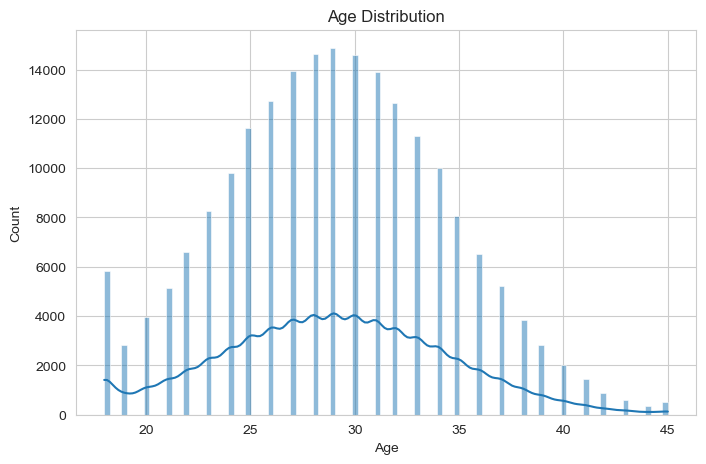

In [100]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Text(0.5, 1.0, 'Monthly Income Distribution')

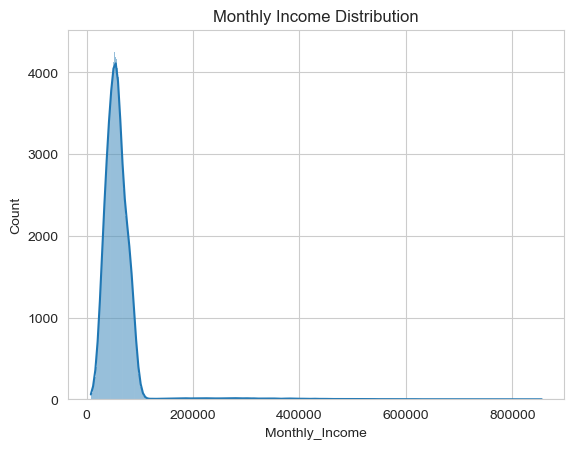

In [99]:
# Income Distribution

sns.histplot(df['Monthly_Income'], kde=True)
plt.title("Monthly Income Distribution")

<Axes: xlabel='Order_Amount_INR'>

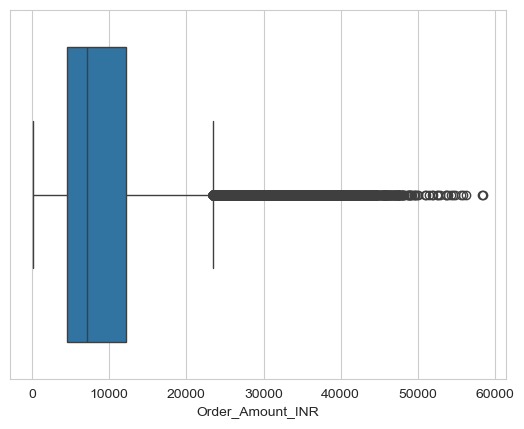

In [98]:
# Order Amount Distribution

sns.boxplot(x=df['Order_Amount_INR'])

## Step 7 – Bivariate Analysis

<Axes: xlabel='Monthly_Income', ylabel='Total_Order_INR'>

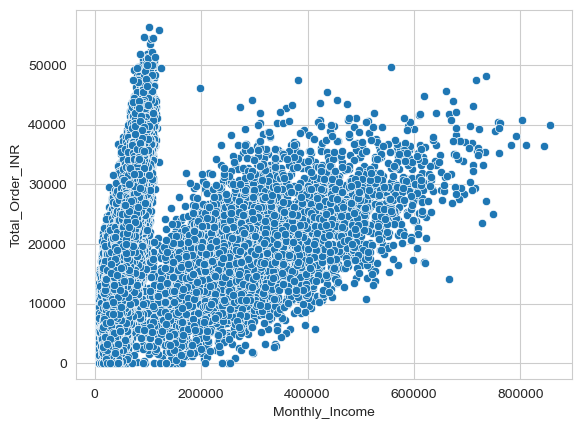

In [97]:
# Income vs Total Spending

sns.scatterplot(
    x='Monthly_Income',
    y='Total_Order_INR',
    data=df
)

<Axes: xlabel='Gender', ylabel='Total_Order_INR'>

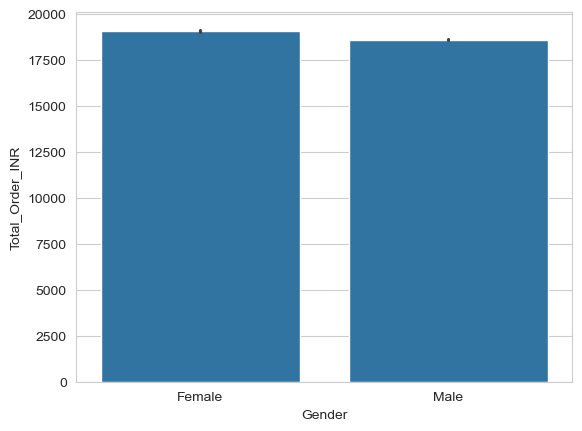

In [103]:
# Gender vs Spending

sns.barplot(
    x='Gender',
    y='Total_Order_INR',
    data=df
)

<Axes: xlabel='Education_Level', ylabel='Total_Order_INR'>

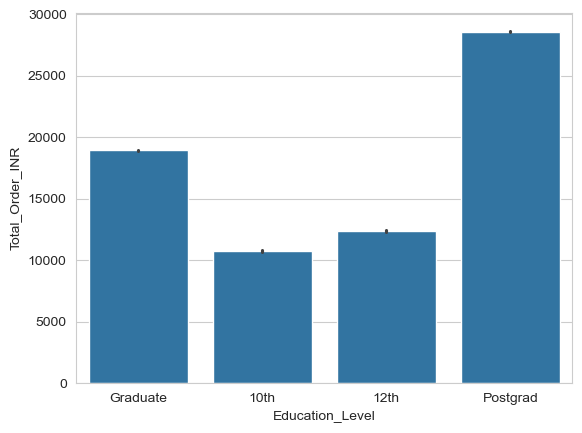

In [104]:
# Education vs Spending

sns.barplot(
    x='Education_Level',
    y='Total_Order_INR',
    data=df
)

## Step 8 – City Revenue Analysis

Text(0.5, 1.0, 'Top Cities by Revenue')

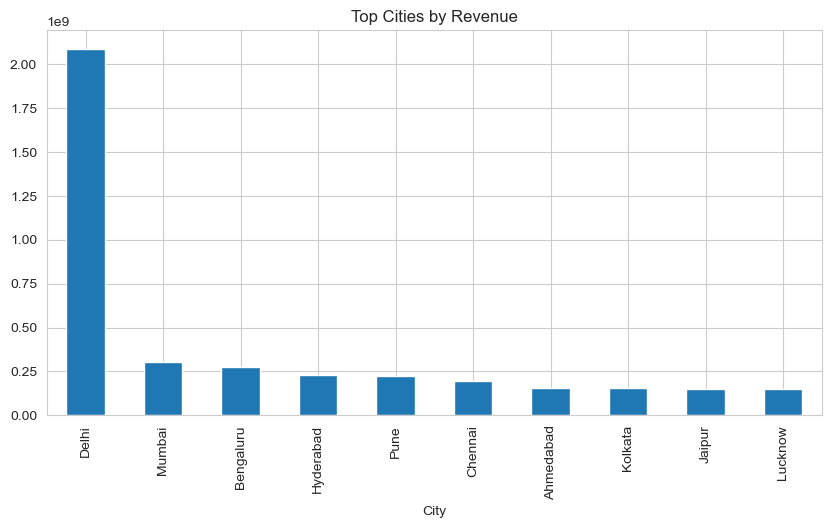

In [105]:
# Which cities generate highest revenue?

city_sales = df.groupby('City')['Total_Order_INR'].sum().sort_values(ascending=False)

city_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Cities by Revenue")

## Step 9 – Income Group vs Spending

In [61]:
df.columns

Index(['user_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Monthly_Income',
       'Marriage_Status', 'Date_of_order', 'Product_order_count',
       'Order_Amount_INR', 'Wallet_Balance_INR', 'Total_Order_INR',
       'avg_order_value', 'income_group'],
      dtype='object')

<Axes: xlabel='income_group', ylabel='Total_Order_INR'>

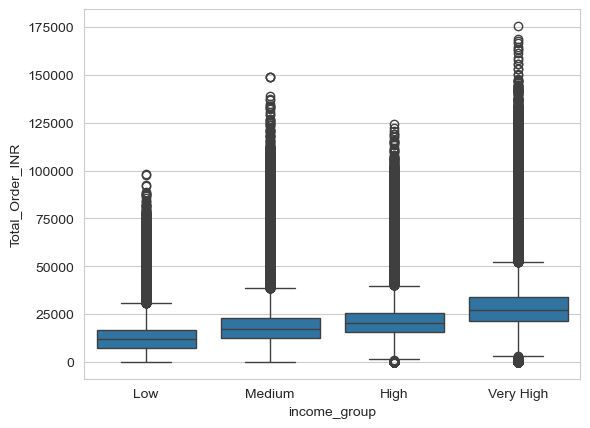

In [57]:
sns.boxplot(
    x='income_group',
    y='Total_Order_INR',
    data=df
)

## Step 10 – Correlation Analysis

<Axes: >

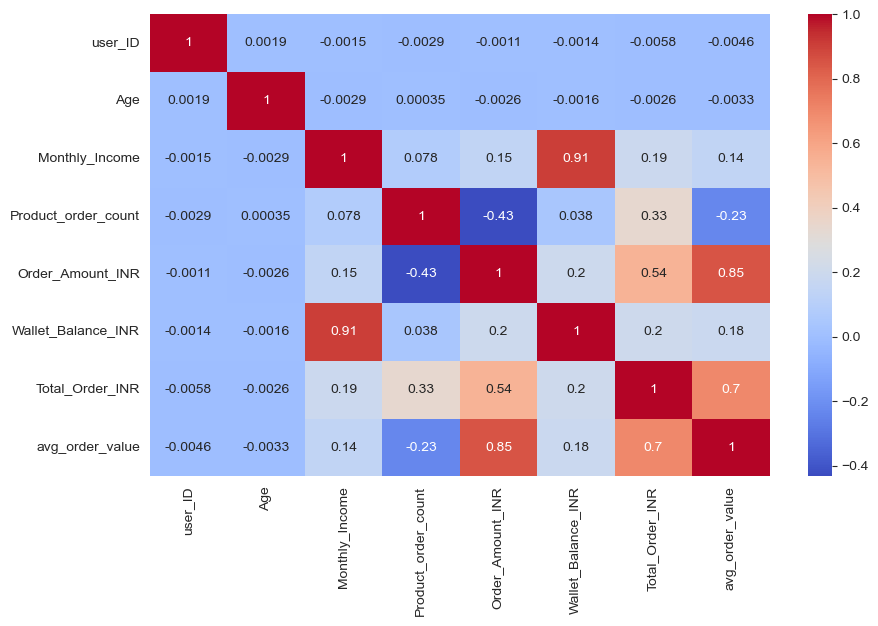

In [58]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

## Step 11 – Customer Segmentation Insight

In [59]:
# High Value Customers

high_value = df[df['Total_Order_INR'] > df['Total_Order_INR'].quantile(0.75)]

In [60]:
high_value['City'].value_counts().head()

City
Unknown    59273
Name: count, dtype: int64

## Step 12 – Business Insights

## 1. Customer Age Distribution 

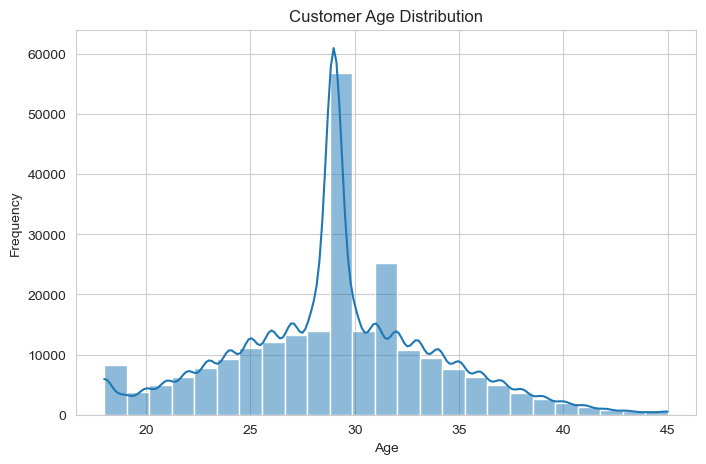

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins = 25, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 2. Income Distribution

In [66]:
df['Monthly_Income'].describe()

count    237106.000000
mean      59964.630566
std       40948.885446
min        8000.000000
25%       44574.000000
50%       55200.500000
75%       66717.000000
max      855162.000000
Name: Monthly_Income, dtype: float64

In [67]:
df['Monthly_Income'].sort_values(ascending=False).head(10)

96315     855162.0
189702    844371.0
131385    809598.0
118665    802948.0
140476    791403.0
69388     783078.0
167381    761729.0
167935    758874.0
173776    758804.0
86414     758147.0
Name: Monthly_Income, dtype: float64

In [69]:
(df['Monthly_Income'] > 100000).sum()

np.int64(4938)

In [70]:
(df['Monthly_Income'] > 100000).mean() * 100

np.float64(2.082612839826913)

Text(0.5, 1.0, 'Income Distribution')

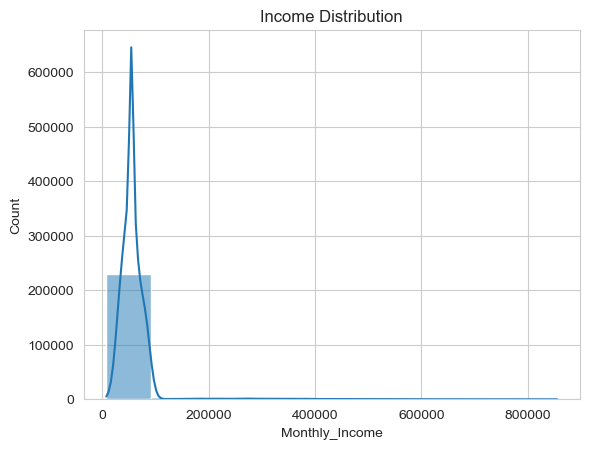

In [68]:
sns.histplot(df['Monthly_Income'], bins = 10, kde=True)
plt.title("Income Distribution")

## 3. Order Amount Outliers 

In [74]:
df['Order_Amount_INR'].describe()

count    237106.000000
mean       9161.703179
std        6681.852279
min          50.000000
25%        4804.250000
50%        7146.000000
75%       11272.000000
max       58515.000000
Name: Order_Amount_INR, dtype: float64

In [73]:
df['Order_Amount_INR'].sort_values(ascending=False).head(10)

66877     58515.0
247340    58384.0
103057    56280.0
51159     55920.0
4289      55596.0
162856    54824.0
16695     54556.0
61955     54290.0
28315     53872.0
86897     53662.0
Name: Order_Amount_INR, dtype: float64

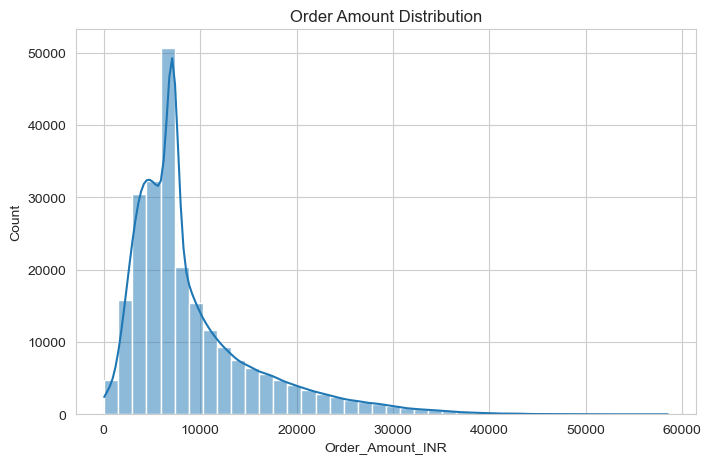

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(df['Order_Amount_INR'], bins=40, kde=True)

plt.title("Order Amount Distribution")
plt.show()

## 4. Income vs Spending Relationship

<Axes: xlabel='Monthly_Income', ylabel='Total_Order_INR'>

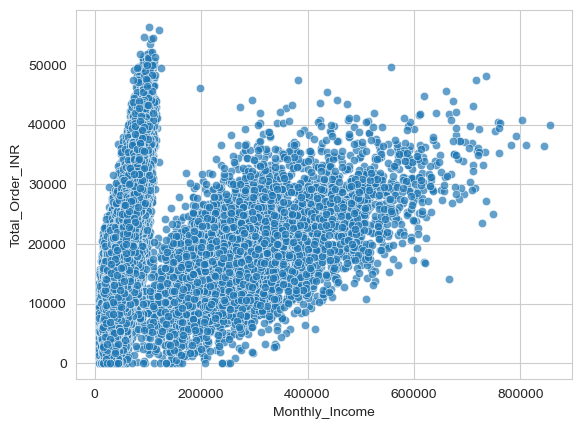

In [115]:
sns.scatterplot(
    x='Monthly_Income',
    y='Total_Order_INR',
    data=df,
    alpha = 0.7
)

## 5. Gender vs Spending

In [116]:
df['Gender'].value_counts()

Gender
Male      151124
Female     98876
Name: count, dtype: int64

In [117]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

Text(0.5, 1.0, 'Spending Distribution by Gender')

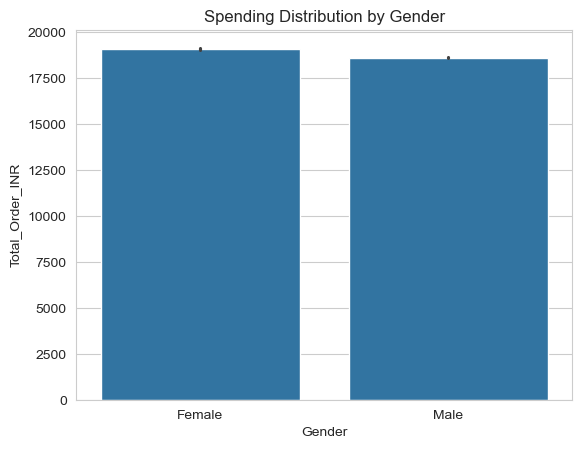

In [122]:
sns.barplot(
    x='Gender',
    y='Total_Order_INR',
    data=df
)
plt.title("Spending Distribution by Gender")

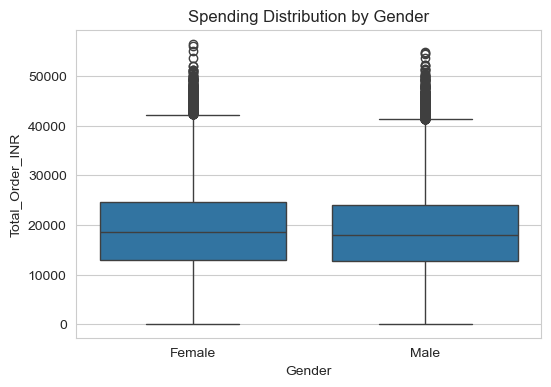

In [121]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='Gender',
    y='Total_Order_INR',
    data=df
)

plt.title("Spending Distribution by Gender")
plt.show()

## 6. Top CIties by Revenue

In [123]:
df['City'].value_counts().head(10)

City
Delhi        112019
Mumbai        15098
Bengaluru     14013
Hyderabad     11802
Pune          11657
Chennai       10346
Ahmedabad      9474
Jaipur         9396
Lucknow        9383
Kolkata        9312
Name: count, dtype: int64

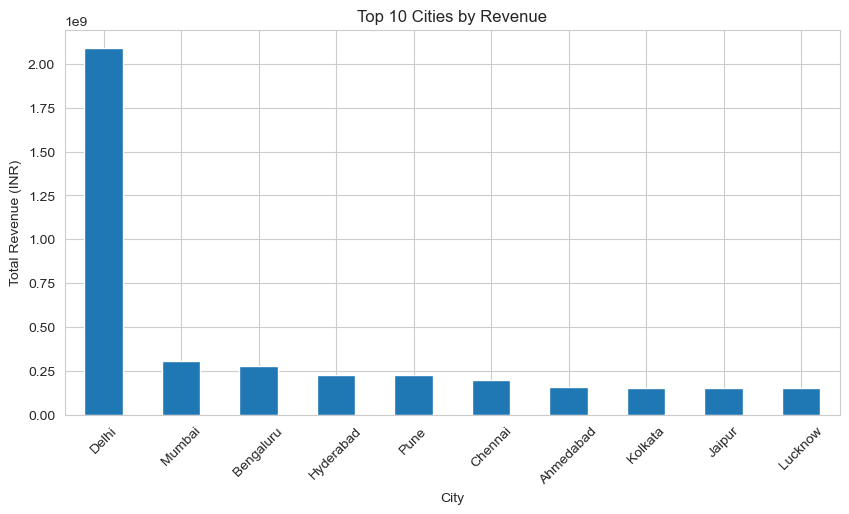

In [131]:
plt.figure(figsize=(10,5))

city_sales = df.groupby('City')['Total_Order_INR'].sum().sort_values(ascending=False)

city_sales.head(10).plot(kind='bar')

plt.title("Top 10 Cities by Revenue")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

### Average spending per city

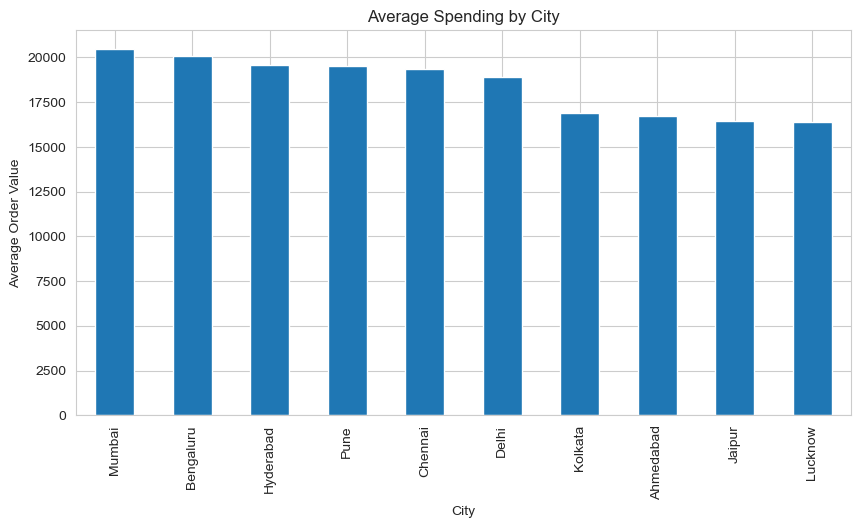

In [126]:
city_avg = df.groupby('City')['Total_Order_INR'].mean().sort_values(ascending=False)

city_avg.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Average Spending by City")
plt.ylabel("Average Order Value")
plt.show()

## 7. Income Group vs Spending

In [137]:
df['income_group'] = pd.qcut(
    df['Monthly_Income'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

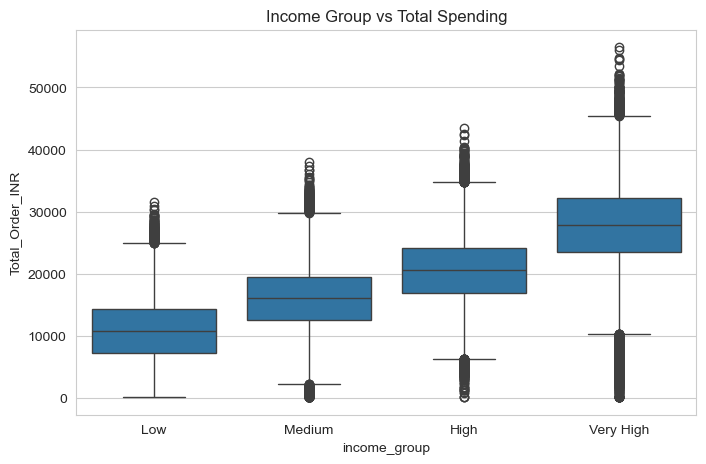

In [139]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='income_group',
    y='Total_Order_INR',
    data=df
)

plt.title("Income Group vs Total Spending")
plt.show()

## 8. Correlation Heatmap

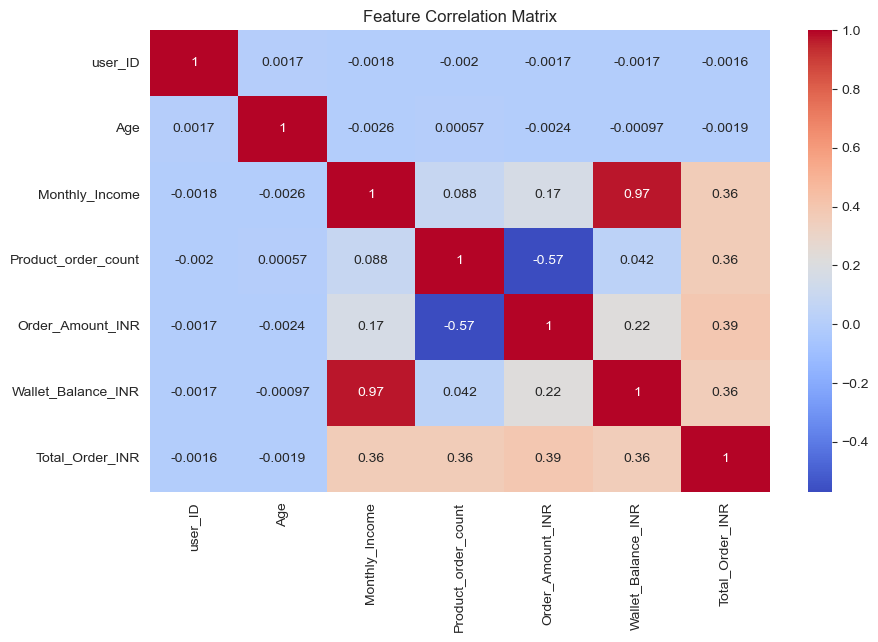

In [142]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

## 9. Order Trend Over Time

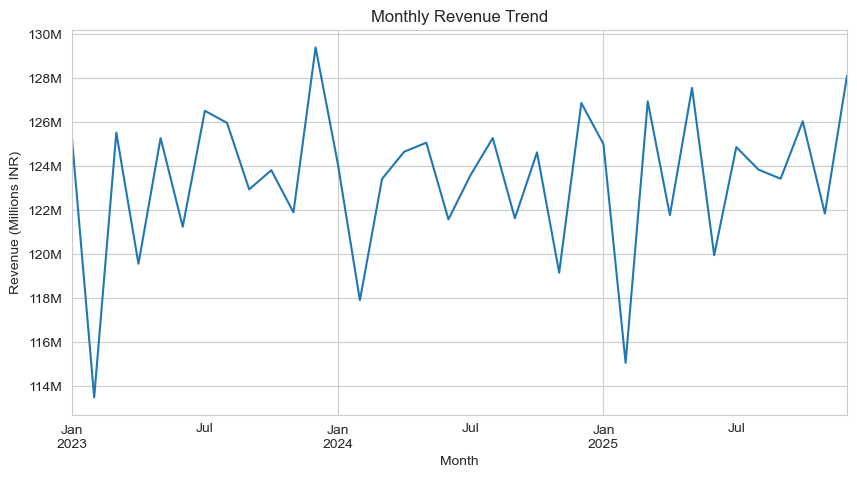

In [147]:
#df['Date_of_order'] = pd.to_datetime(df['Date_of_order'], dayfirst=True)
df['Date_of_order'] = pd.to_datetime(
    df['Date_of_order'],
    dayfirst=True,
    errors='coerce' # converts invalid dates into NaT instead of crashing.
)

monthly_sales = df.groupby(
    df['Date_of_order'].dt.to_period('M')
)['Total_Order_INR'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions INR)")

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')

plt.show()

## 10. High-Value Customer Distribution

<Axes: xlabel='City', ylabel='count'>

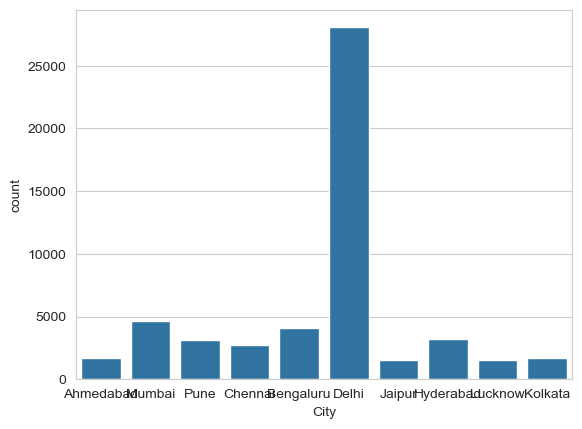

In [152]:
high_value = df[df['Total_Order_INR'] > df['Total_Order_INR'].quantile(0.75)]

sns.countplot(x='City', data=high_value)